### Preparando o ambiente

## O que é tensorflow  

Tensorflow é uma biblioteca com várias funcionalidades voltadas para Machine Learning

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.datasets import cifar10, fashion_mnist

import matplotlib.pyplot as plt
import numpy as np

### Carregando os dados

In [ ]:
# Carregando os dados
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Mostrando o tamanho do dataset (dimensão)
print("Dimensões do conjunto de treinamento:", X_train.shape)
print("Dimensões do conjunto de teste:", X_test.shape)

# Classes presentes no dataset
classes = ['Avião', 'Automóvel', 'Pássaro', 'Gato', 'Veado', 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis('off')
plt.show()

### Separando os dados entre treino e teste

In [ ]:
# Essa parte serve mais para a normalização dos dados, pois estamos tratando de imagens nesse exemplo
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# Construindo o modelo de CNN
# A estrutura do modelo é a seguinte:
# 1. Camada de convolução com 32 filtros de 3x3 e função de ativação ReLU
# 2. Camada de MaxPooling de 2x2
# 3. Camada de convolução com 64 filtros de 3x3 e função de ativação ReLU
# 4. Camada de MaxPooling de 2x2
# 5. Camada de convolução com 128 filtros de 3x3 e função de ativação ReLU
# 6. Camada de Flatten: transforma a matriz em um vetor (imagens 2D para 1D)
# 7. Camada Dense (128 neurônios) com função de ativação ReLU (camada oculta)
# 8. Dropout de 50%: zera 50% dos valores de entrada, evitando overfitting
# 9. Camada Dense (10 neurônios) com função de ativação softmax (camada de saída)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Para evitar overfitting
    Dense(10, activation='softmax')
])

# Resumo do modelo
model.summary()

In [ ]:
# Compilando o modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Treinando o modelo
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

In [ ]:
# Avaliar o modelo no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

In [ ]:
# Plotar perda e acurácia
plt.figure(figsize=(12, 4))

# Perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.show()

### Agora, vamos testar usando data augmentation

In [ ]:
# Isso é um simples exemplo de como podemos aumentar o dataset, no caso, estamos aumentando as imagens
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Aplicando tudo
datagen.fit(X_train)

# Agora, vamos retreinar o modelo usando o conjunto de dados novo e ver se houve alguma mudança
model.fit(datagen.flow(X_train, y_train, batch_size=64), epochs=10, validation_data=(X_test, y_test))

In [ ]:
# Novamente, devemos avaliar o modelo no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

In [ ]:
# Plotando os gráficos de perda e acurácia
plt.figure(figsize=(12, 4))

# Perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.show()

# Agora é a sua vez de fazer uma rede de aprendizado profundo usando o dataset
## [Fashion-Mnist](https://www.kaggle.com/datasets/zalando-research/fashionmnist/data)!

**.load_data()**: função que carrega os dados do dataset fashion_mnist  
  
  **(X_train, y_train)**:  
    
  X_train é o conjuto de imagens que serão usadas para treinamento  
  Y_train é o conjunto de rótulos associados a cada imagem  

**(X_test, Y_test)**:  

  X_test é o conjunto de imagens de treinamento  
  t_test é o conjunto de rótulos  
    
**o que tem X_train**: matriz de imagens  
**O que há em y_train**: números que representam a qual classe a imagem apontada por eles representa  
9 é ankle boot  
6 é shirt  
e por aí vai...


Dimensões do conjunto de treinamento: (60000, 28, 28)
Dimensões do conjunto de teste: (10000, 28, 28)


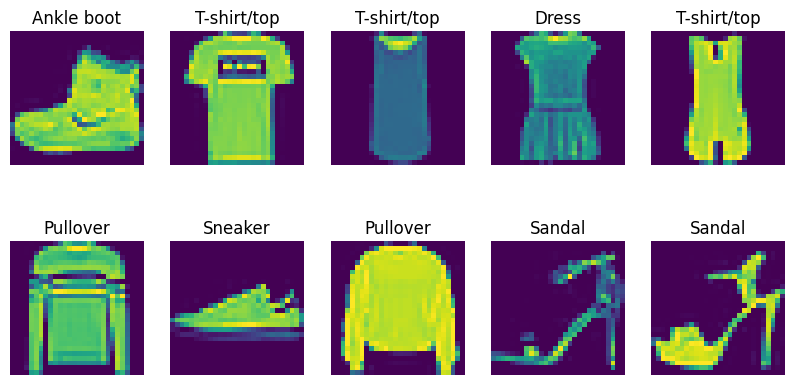

In [119]:
# a divisão entre treino e teste foi definida antes, pelos criadores do dataset fashion_mnist
# X_train contém matrizes e y_train contém numeros que representam as classes

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data() # carrega o dataset e o retorna separado entre treino e teste

# Mostrando o tamanho do dataset (dimensão)
print("Dimensões do conjunto de treinamento:", X_train.shape)
print("Dimensões do conjunto de teste:", X_test.shape)

# Classes presentes no dataset
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#cria uma área para plotar gráficos
plt.figure(figsize=(10, 5)) # define o tamanho do eixo X e eixo Y
for i in range(10):
    # como o eixo do gráfico tem X = 10 e y = 5, então o gráfico é dividido em 10 partes iguais
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i]) #imprime a imagem 
    plt.title(classes[y_train[i]]) #imprime o nome da classe em cada subplot
    plt.axis('off')
plt.show()

## Normalização  

Para o modelo,é melhor colocar alguns valores entre [0, 1], afim de que não atribue pesos diferentes aos valores, isto é, julgar algo como mais importante ou não.  
  
    
## Aqui normalizamos pelo range de RGB  
Cada item de X_train e X_test é uma matriz de numeros entre 0 e 255, que representam as cores na escala RGB. Assim, queremos normalizá-los entre [0,1]


## reshape():  
É necessário adicionar uma dimensão em X_train e X_teste, pois ao utilizar o data augmentation, precisamos passá-lo com 4 dimensões

In [120]:
# Essa parte serve mais para a normalização dos dados, pois estamos tratando de imagens nesse exemplo

# Sintaxe permitida somente em arrays numpy, pois ele aplica a divisao por 255 em qualquer numero que estiver nesse array
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# Transforma isso em uma matriz com OneHotEncoding
# Converte os números de cada classe para varias colunas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [121]:
# Construindo o modelo de CNN
# A estrutura do modelo é a seguinte:
# 1. Camada de convolução com 32 filtros de 3x3 e função de ativação ReLU
# 2. Camada de MaxPooling de 2x2
# 3. Camada de convolução com 64 filtros de 3x3 e função de ativação ReLU
# 4. Camada de MaxPooling de 2x2
# 5. Camada de convolução com 128 filtros de 3x3 e função de ativação ReLU
# 6. Camada de Flatten: transforma a matriz em um vetor (imagens 2D para 1D)
# 7. Camada Dense (128 neurônios) com função de ativação ReLU (camada oculta)
# 8. Dropout de 50%: zera 50% dos valores de entrada, evitando overfitting
# 9. Camada Dense (10 neurônios) com função de ativação softmax (camada de saída)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Para evitar overfitting
    Dense(10, activation='softmax')
])

# Resumo do modelo
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

**Validação**: durante o treinamento, dividimos o dataset X_train em duas partes:  
1. Dados que a IA deve aprender  
2. Dados para testar o desenvolvmento da IA durante o treinamento  

**Como acontece o treinamento**:  

**Cada epoch equivale a quantas vezes o modelo vai rodar**  
**O modelo atualiza os pesos varias vezes durante uma época**, mas ele só atualiza os pesos a um número "batch_size" de amostras.  
Durante o treinamento, ele divide os dados de validação e de treino

In [122]:
# Compilando o modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Treinando o modelo

# epochs é a quantidade de vezes que vai rodar
# batch_size é a quantidade de amostras que ele deve rodar sem atualizar os peso
# validation_split são quantos dados de X_train serão divididos para validação 

history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6569 - loss: 0.9302 - val_accuracy: 0.8514 - val_loss: 0.4029
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8410 - loss: 0.4425 - val_accuracy: 0.8640 - val_loss: 0.3534
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8684 - loss: 0.3596 - val_accuracy: 0.8882 - val_loss: 0.3085
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8833 - loss: 0.3220 - val_accuracy: 0.8909 - val_loss: 0.2845
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8973 - loss: 0.2859 - val_accuracy: 0.8913 - val_loss: 0.2952
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9069 - loss: 0.2643 - val_accuracy: 0.9018 - val_loss: 0.2659
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9092 - loss: 0.2472 - val_accuracy: 0.9038 - val_loss: 0.2599
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9200 - loss: 0.2228 - 

In [123]:
# Avaliar o modelo no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

313/313 - 1s - 3ms/step - accuracy: 0.9096 - loss: 0.2587
Acurácia no conjunto de teste: 90.96%


## Perda:
Mede quando o modelo pode errar. Conhecido com "função de erro" indica a diferença entre o valor predito e o valor real
## Validação:
Quanto o modelo acerta com dados que estão fora do dataset
## Acurácia:
Indica quantas respostas foram corretas 

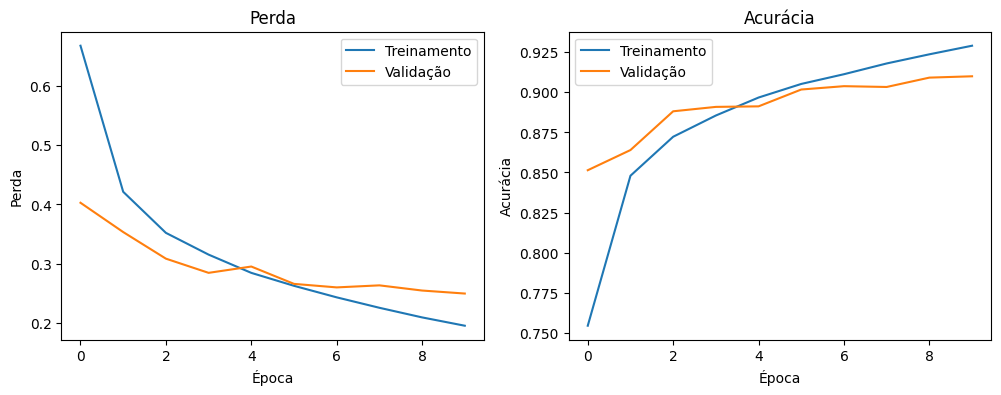

In [124]:
# Plotar perda e acurácia
plt.figure(figsize=(12, 4))

# Perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.show()

## O que é Data Augmentation: 
Forma de alterar os dados que já existem e treinar o modelo de novo com dados alterados, para que fique mais preciso

In [125]:
# Isso é um simples exemplo de como podemos aumentar o dataset, no caso, estamos aumentando as imagens
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Aplicando tudo
datagen.fit(X_train)

# Agora, vamos retreinar o modelo usando o conjunto de dados novo e ver se houve alguma mudança
model.fit(datagen.flow(X_train, y_train, batch_size=64), epochs=10, validation_data=(X_test, y_test),)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.6548 - loss: 0.9739 - val_accuracy: 0.8638 - val_loss: 0.3930
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7760 - loss: 0.5971 - val_accuracy: 0.8559 - val_loss: 0.4144
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8027 - loss: 0.5368 - val_accuracy: 0.8722 - val_loss: 0.3663
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8156 - loss: 0.5012 - val_accuracy: 0.8745 - val_loss: 0.3457
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8315 - loss: 0.4700 - val_accuracy: 0.8742 - val_loss: 0.3559
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8383 - loss: 0.4537 - val_accuracy: 0.8619 - val_loss: 0.3860
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8364 - loss: 0.4516 - val_accuracy: 0.8786 - val_loss: 0.3470
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8432 - loss: 0.4357 - 

In [126]:
# Novamente, devemos avaliar o modelo no conjunto de teste
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Acurácia no conjunto de teste: {test_acc * 100:.2f}%")

313/313 - 1s - 3ms/step - accuracy: 0.8850 - loss: 0.3215
Acurácia no conjunto de teste: 88.50%


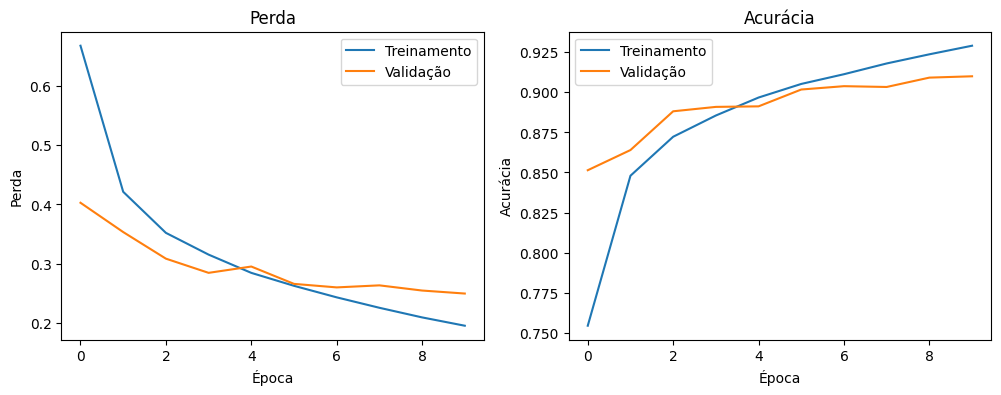

In [127]:
# Plotando os gráficos de perda e acurácia
plt.figure(figsize=(12, 4))

# Perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.show()